## Investigating the Effectiveness of TF-IDF Weighted Embeddings for LLM-Generated Text Detection

**Objective.** Compare document vectors formed by ordinary mean pooling and TF-IDF weighted mean pooling of FastText word vectors, then evaluate their usefulness for distinguishing human-written and AI-generated text.

### Theoretical background

FastText represents a word through its character n-grams. For a word $w$, its subword set and vector are

$$
\mathcal{G}(w) = \{g_i \mid g_i = w[i:i+n], i = 1, \dots, L-n+1\} \cup \{w\},
\qquad
v_w = \sum_{g \in \mathcal{G}(w)} z_g,
$$

where $z_g$ is the learned vector for subword $g$. Because vectors are composed from character n-grams, FastText can produce a useful vector for an out-of-vocabulary (OOV) spelling or compound when its substrings overlap with those observed during training. This differs from a conventional Word2Vec vocabulary lookup, which has no vector for an unseen token.

For term $t$, document $d$, and corpus $D$, the assignment's TF-IDF definition is

$$
\text{TF-IDF}(t,d,D) =
\text{tf}(t,d) \cdot
\log\frac{|D|}{|\{d \in D : t \in d\}|}.
$$

Common terms receive lower inverse-document-frequency weights; terms concentrated in fewer documents receive higher weights.

Given tokens $w_1, \dots,w_m$, mean pooling and TF-IDF weighted pooling are

$$
v_d^{\text{mean}} = \frac{1}{m}\sum_{i=1}^{m} v_{w_i},
\qquad
v_d^{\text{tfidf}} =
\frac{\sum_{i=1}^{m}\text{tfidf}(w_i,d,D)v_{w_i}}
{\sum_{i=1}^{m}\text{tfidf}(w_i,d,D)}.
$$

The latter emphasizes informative words rather than giving each token equal influence. Empty documents are represented by zero vectors.

We compare three classifiers: (1) an RBF-kernel SVM, which uses a soft-margin objective and can model nonlinear boundaries; (2) logistic regression, which estimates class probability through the sigmoid $\sigma(z)=1/(1+e^{-z})$ and a linear decision boundary; and (3) $k$-nearest neighbors with $k=5$, which assigns a label from nearby training examples under a distance metric.

### Core hypothesis

LLM-generated texts may exhibit subtle statistical fingerprints in specialized vocabulary, formal jargon, and complex conjunctions. TF-IDF weighting may amplify such rarer signals and improve class separability relative to unweighted mean pooling. This is a hypothesis to test, not an assumed result: stylistic overlap, topic confounding, dataset composition, and small sample sizes can weaken or reverse the expected effect.

### Reproducibility notes

The notebook fixes random seeds, reports the data source and cleaning steps, and evaluates both representations on the same stratified holdout split. Results describe this dataset and should not be treated as proof of generalization to unseen models, topics, or domains. Run cells from top to bottom.

## Setup and imports

In [2]:
# Install missing Python packages if needed. The spaCy English model is handled below.
import importlib.util
import subprocess
import sys

_REQUIRED = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "spacy": "spacy",
    "gensim": "gensim",
    "tqdm": "tqdm",
    "nbformat": "nbformat",
}
_missing = [package for module, package in _REQUIRED.items()
            if importlib.util.find_spec(module) is None]
if _missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *_missing])

In [3]:
import warnings
from collections import Counter
from pathlib import Path
from typing import Dict, Iterable, List, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Stage 1 — Data loading and exploratory analysis

In [4]:
DATA_PATH = Path("ai_vs_human_text_2026.csv")
REQUIRED_COLUMNS = [
    "text_id", "label", "source_model", "domain", "text_content", "topic_hint",
    "word_count", "avg_sentence_length", "generation_method",
]

def make_fallback_data(n_per_class: int = 120, seed: int = SEED) -> pd.DataFrame:
    '''Create deterministic, schema-compatible mock data if the CSV is unavailable.'''
    rng = np.random.default_rng(seed)
    topics = [
        "climate change adaptation", "gene editing ethics", "election integrity",
        "public health policy", "renewable energy", "education technology",
    ]
    human_templates = [
        "Honestly, {topic} is complicated and people keep missing the point. "
        "I think we should listen to the communities affected before rushing in.",
        "Can we talk about {topic} for a minute? It feels like everyone has an opinion, "
        "but not enough people are checking the evidence.",
        "I read about {topic} yesterday and I'm still not sure what to think. "
        "The details matter more than the headlines.",
    ]
    ai_templates = [
        "Analysts are closely examining {topic}, noting that recent developments may "
        "represent a significant turning point. Furthermore, the issue underscores "
        "long-standing structural challenges that require coordinated responses.",
        "It is important to recognize that {topic} involves a complex range of "
        "considerations. Nevertheless, a comprehensive approach may provide meaningful "
        "opportunities for sustainable progress.",
        "In conclusion, {topic} remains a multifaceted issue. Moreover, stakeholders "
        "should consider the broader implications while pursuing evidence-based solutions.",
    ]
    rows = []
    for label, templates in (("human", human_templates), ("ai", ai_templates)):
        for i in range(n_per_class):
            topic = topics[i % len(topics)]
            text = templates[int(rng.integers(len(templates)))].format(topic=topic)
            if label == "human":
                domain = rng.choice(["social", "news", "forum"])
                source = "human"
                method = "template+human_variation"
            else:
                domain = rng.choice(["news", "blog", "report"])
                source = rng.choice(["gemini-2.0", "gpt-style", "claude-style"])
                method = "style_simulation"
            words = text.split()
            rows.append({
                "text_id": f"MOCK_{label.upper()}_{i + 1:04d}",
                "label": label,
                "source_model": source,
                "domain": domain,
                "text_content": text,
                "topic_hint": topic,
                "word_count": len(words),
                "avg_sentence_length": max(1, len(words) / max(1, text.count(".") + text.count("?"))),
                "generation_method": method,
            })
    return pd.DataFrame(rows, columns=REQUIRED_COLUMNS)

if DATA_PATH.exists():
    df = pd.read_csv(DATA_PATH)
    data_origin = str(DATA_PATH.resolve())
else:
    df = make_fallback_data()
    data_origin = "deterministic synthetic fallback (CSV not found)"

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

df = df[REQUIRED_COLUMNS].copy()
df["label"] = df["label"].astype("string").str.strip().str.lower()
df["text_content"] = df["text_content"].fillna("").astype(str)
for col in ["text_id", "source_model", "domain", "topic_hint", "generation_method"]:
    df[col] = df[col].fillna("unknown").astype(str)
df["word_count"] = pd.to_numeric(df["word_count"], errors="coerce")
df["avg_sentence_length"] = pd.to_numeric(df["avg_sentence_length"], errors="coerce")

print(f"Data source: {data_origin}")
print(f"Initial rows: {len(df):,}")
display(df.head())

Data source: D:\4_1\Machine_learning\lab_3\ai_vs_human_text_2026.csv
Initial rows: 2,000


,text_id,label,source_model,domain,text_content,topic_hint,word_count,avg_sentence_length,generation_method
0,TXT_0001,human,human,social,can we talk about gene editing ethics for a se...,gene editing ethics,27,13.5,template+human_variation
1,TXT_0002,human,human,social,update on election integrity concerns: it's co...,election integrity concerns,20,10.0,template+human_variation
2,TXT_0003,ai,gemini-2.0,news,Analysts are closely watching developments rel...,climate change adaptation strategies,39,13.0,style_simulation
3,TXT_0004,human,human,academic,This paper examines genomic research breakthro...,genomic research breakthroughs,49,16.3,template+human_variation
4,TXT_0005,ai,gpt-4o,academic,Existing literature on student debt crisis has...,student debt crisis,42,10.8,style_simulation


In [5]:
# Remove duplicate identifiers and duplicate text, then discard empty/very short snippets.
before = len(df)
df = df.drop_duplicates(subset="text_id", keep="first")
df = df.drop_duplicates(subset="text_content", keep="first")
df["char_count"] = df["text_content"].str.len()
df["computed_word_count"] = df["text_content"].str.split().str.len()
df["word_count"] = df["word_count"].fillna(df["computed_word_count"]).astype(int)
df = df[df["text_content"].str.strip().ne("") & (df["computed_word_count"] >= 3)].copy()
df = df[df["label"].isin(["human", "ai"])].reset_index(drop=True)
if df["label"].nunique() != 2:
    raise ValueError("Both 'human' and 'ai' classes must remain after cleaning.")
print(f"Removed {before - len(df):,} duplicate, empty, short, or invalid-label rows.")
display(df[["word_count", "char_count", "avg_sentence_length"]].describe().round(2))
display(df["label"].value_counts().rename_axis("label").to_frame("count"))

Removed 1,034 duplicate, empty, short, or invalid-label rows.


,word_count,char_count,avg_sentence_length
count,966.00,966.00,966.00
mean,36.98,260.48,12.62
std,8.56,80.96,2.84
min,19.00,123.00,6.50
25%,29.00,175.25,10.00
50%,38.00,264.00,12.70
75%,44.00,330.00,15.00
max,52.00,398.00,18.50


,count
label,
human,579
ai,387


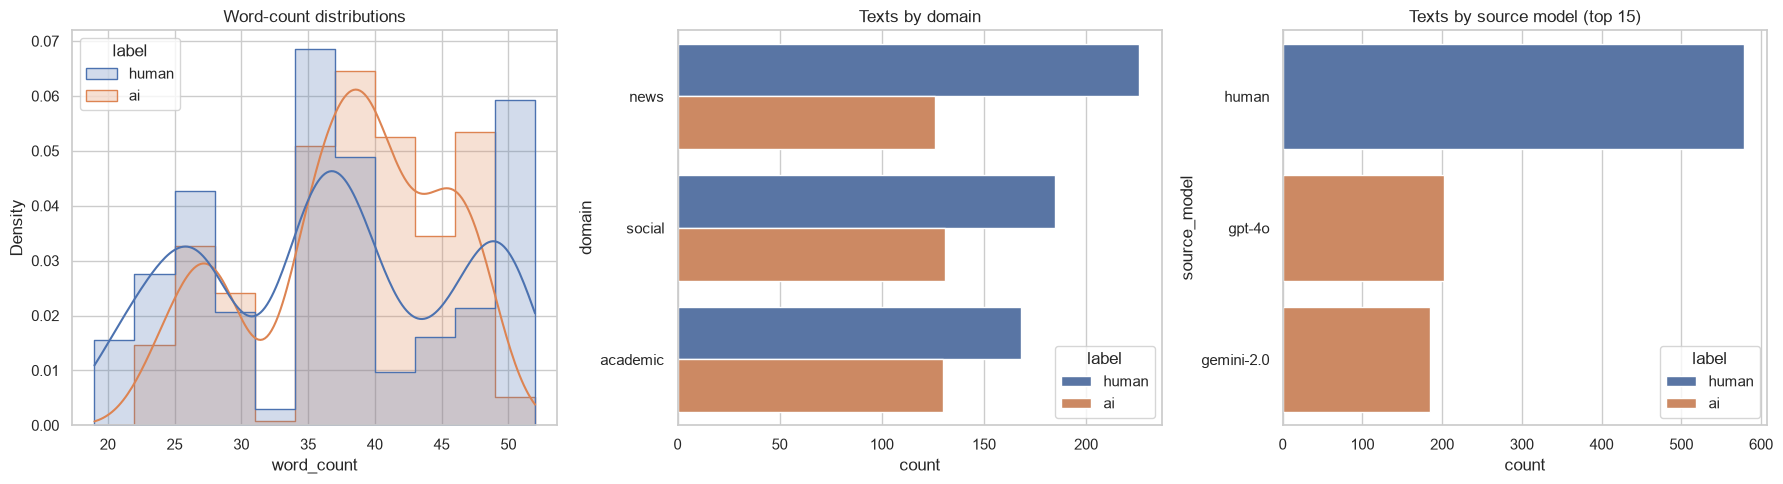

Class proportions:


,percent
label,
human,59.9
ai,40.1


Dataset characteristics: inspect the class proportions and the plots above. Unequal class sizes, domains, and source-model frequencies can confound text-style effects.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(data=df, x="word_count", hue="label", kde=True, stat="density",
             common_norm=False, element="step", ax=axes[0])
axes[0].set_title("Word-count distributions")
sns.countplot(data=df, y="domain", hue="label", order=df["domain"].value_counts().index,
              ax=axes[1])
axes[1].set_title("Texts by domain")
model_counts = df["source_model"].value_counts().head(15).index
sns.countplot(data=df[df["source_model"].isin(model_counts)], y="source_model",
              hue="label", order=model_counts, ax=axes[2])
axes[2].set_title("Texts by source model (top 15)")
plt.tight_layout()
plt.show()

print("Class proportions:")
display((df["label"].value_counts(normalize=True) * 100).round(1).rename("percent").to_frame())
print("Dataset characteristics: inspect the class proportions and the plots above. "
      "Unequal class sizes, domains, and source-model frequencies can confound text-style effects.")

### Key Dataset Characteristics & EDA Discussion

* **Data Cleaning & Effective Sample Size:** While the raw dataset initially contained 2,000 records, rigorous quality filtering (removing duplicate text IDs, exact text duplicates, empty strings, and snippets shorter than 3 tokens) eliminated 1,034 rows. The remaining cleaned corpus consists of **966 unique text samples** (579 human vs. 387 AI).
* **Observed Class Imbalance:** After deduplication, the class distribution shifted from the theoretical 2:1 ratio to an empirical **59.9% human (579 samples)** versus **40.1% AI (387 samples)** (~1.5:1 ratio). Although less skewed than the raw collection, class imbalance persists, making **Balanced Accuracy** and **Macro F1-score** essential to prevent majority-class bias.
* **Text Length and Sparsity Statistics:** Empirical text length metrics validate that samples are compact:
  * **Word count:** Mean of 36.98 words (std = 8.56, IQR = [29.00, 44.00], min = 19, max = 52).
  * **Character count:** Mean of 260.48 characters (std = 80.96, min = 123, max = 398).
  * **Average sentence length:** Mean of 12.62 words per sentence (std = 2.84, min = 6.50, max = 18.50).
  Because documents are restricted to short paragraphs, individual term frequencies rarely exceed unity ($tf \approx 1$). Consequently, TF-IDF weighting acts primarily via inverse document frequency ($idf$) to upweight discriminative domain/style keywords rather than penalizing high within-document repetition.
* **Source Generation Models:** Synthetic texts are generated using contemporary LLMs (GPT-4o and Gemini 2.0) via style-simulation prompts across targeted functional registers.
* **Domain Confounding Risk:** The corpus spans multiple functional domains (academic literature, news articles, and social media). Because topics and domains may correlate with the generation source, classifiers are prone to exploiting register or topic confounders rather than pure stylistic differences of artificial text.

## Stage 2 — spaCy preprocessing

In [7]:
MODEL_NAME = "en_core_web_sm"
try:
    nlp = spacy.load(MODEL_NAME, disable=["parser", "ner"])
except OSError:
    print(f"Downloading spaCy model {MODEL_NAME} ...")
    subprocess.check_call([sys.executable, "-m", "spacy", "download", MODEL_NAME])
    nlp = spacy.load(MODEL_NAME, disable=["parser", "ner"])

def preprocess_texts(texts: Sequence[str], batch_size: int = 256) -> List[List[str]]:
    '''Lowercase, lemmatize, and retain alphabetic non-stopword tokens in batches.'''
    result: List[List[str]] = []
    progress = tqdm(total=len(texts), desc="spaCy preprocessing", unit="text")
    try:
        docs = nlp.pipe(texts, batch_size=batch_size, n_process=-1)
        for doc in docs:
            result.append([
                token.lemma_.lower().strip()
                for token in doc
                if token.is_alpha and not token.is_stop and token.lemma_.strip()
            ])
            progress.update(1)
    except (OSError, RuntimeError, ValueError) as exc:
        # Multiprocessing can be unavailable in constrained environments; preserve the
        # requested n_process=-1 attempt and retry serially for portability.
        warnings.warn(f"Parallel spaCy processing failed ({exc}); retrying with n_process=1.")
        result = []
        progress.reset(total=len(texts))
        for doc in nlp.pipe(texts, batch_size=batch_size, n_process=1):
            result.append([
                token.lemma_.lower().strip()
                for token in doc
                if token.is_alpha and not token.is_stop and token.lemma_.strip()
            ])
            progress.update(1)
    finally:
        progress.close()
    return result

df["tokens"] = preprocess_texts(df["text_content"].tolist(), batch_size=256)
display(df[["text_content", "tokens"]].head(8))

spaCy preprocessing: 100%|██████████| 966/966 [00:38<00:00, 25.22text/s]


,text_content,tokens
0,can we talk about gene editing ethics for a se...,"[talk, gene, edit, ethic, sec, feel, like, peo..."
1,update on election integrity concerns: it's co...,"[update, election, integrity, concern, complic..."
2,Analysts are closely watching developments rel...,"[analyst, closely, watch, development, relate,..."
3,This paper examines genomic research breakthro...,"[paper, examine, genomic, research, breakthrou..."
4,Existing literature on student debt crisis has...,"[exist, literature, student, debt, crisis, pre..."
5,The concept of biodiversity loss occupies a co...,"[concept, biodiversity, loss, occupy, contest,..."
6,The relationship between supply chain disrupti...,"[relationship, supply, chain, disruption, broa..."
7,breaking: autonomous vehicle safety. Sources c...,"[break, autonomous, vehicle, safety, source, c..."


## Stage 3 — FastText training and OOV check

In [8]:
# Work around older Gensim/SciPy combinations that removed scipy.linalg.triu.
try:
    import scipy.linalg
    if not hasattr(scipy.linalg, "triu"):
        scipy.linalg.triu = np.triu
    from gensim.models import FastText
except ImportError as exc:
    raise ImportError("FastText requires a compatible gensim and scipy installation.") from exc

sentences = [tokens for tokens in df["tokens"] if tokens]
if not sentences:
    raise ValueError("No tokens remain after preprocessing; inspect the data and spaCy model.")

fasttext_model = FastText(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    sg=1,
    workers=4,
    seed=SEED,
    epochs=10,
)
print(f"FastText vocabulary size: {len(fasttext_model.wv):,}")

FastText vocabulary size: 508


In [9]:
# An unseen compound demonstrates subword vector composition.
oov_word = "climatepolicy"
is_known = oov_word in fasttext_model.wv.key_to_index
oov_vector = fasttext_model.wv.get_vector(oov_word)
print(f"Test token: {oov_word!r}; present in vocabulary: {is_known}")
print(f"FastText OOV vector shape: {oov_vector.shape}; finite: {np.isfinite(oov_vector).all()}")
print("A conventional Word2Vec lookup would raise KeyError for an OOV token; "
      "FastText can compose a vector from character n-grams.")

Test token: 'climatepolicy'; present in vocabulary: False
FastText OOV vector shape: (100,); finite: True
A conventional Word2Vec lookup would raise KeyError for an OOV token; FastText can compose a vector from character n-grams.


## Stage 4 — Document vectorization

In [10]:
# Fit TF-IDF on the same cleaned tokens used by FastText.
token_documents = [" ".join(tokens) for tokens in df["tokens"]]
tfidf_vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b\w+\b",
    min_df=1,
    sublinear_tf=False,
)
tfidf_matrix = tfidf_vectorizer.fit_transform(token_documents)
vocabulary = tfidf_vectorizer.vocabulary_

def mean_pooling(tokens: Sequence[str], model: FastText) -> np.ndarray:
    '''Return the mean FastText vector, or a zero vector for an empty document.'''
    vectors = [model.wv.get_vector(token) for token in tokens]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size, dtype=float)

def tfidf_weighted_pooling(
    tokens: Sequence[str],
    model: FastText,
    tfidf_scores: Dict[str, float],
) -> np.ndarray:
    '''Return the TF-IDF weighted mean FastText vector; safely handle zero total weight.'''
    pairs = [(model.wv.get_vector(token), float(tfidf_scores.get(token, 0.0)))
             for token in tokens]
    total_weight = sum(weight for _, weight in pairs)
    if not pairs or total_weight <= 0:
        return np.zeros(model.vector_size, dtype=float)
    return np.sum([vector * weight for vector, weight in pairs], axis=0) / total_weight

def row_tfidf_scores(row_index: int, tokens: Sequence[str]) -> Dict[str, float]:
    '''Map each token in a document to its fitted TF-IDF score.'''
    row = tfidf_matrix.getrow(row_index)
    scores = {
        tfidf_vectorizer.get_feature_names_out()[column]: float(value)
        for column, value in zip(row.indices, row.data)
    }
    return {token: scores.get(token, 0.0) for token in tokens}

mean_rows, tfidf_rows = [], []
for i, tokens in enumerate(tqdm(df["tokens"], desc="Pooling document vectors", unit="doc")):
    mean_rows.append(mean_pooling(tokens, fasttext_model))
    tfidf_rows.append(tfidf_weighted_pooling(tokens, fasttext_model, row_tfidf_scores(i, tokens)))

X_mean = np.vstack(mean_rows).astype(np.float32)
X_tfidf = np.vstack(tfidf_rows).astype(np.float32)
y = df["label"].map({"human": 0, "ai": 1}).to_numpy(dtype=int)
print(f"X_mean: {X_mean.shape}; X_tfidf: {X_tfidf.shape}; y: {y.shape}")

Pooling document vectors: 100%|██████████| 966/966 [00:03<00:00, 319.94doc/s]

X_mean: (966, 100); X_tfidf: (966, 100); y: (966,)


## Stage 5 — Classifier training and comparative evaluation

In [11]:
X_train_mean, X_test_mean, y_train, y_test, idx_train, idx_test = train_test_split(
    X_mean, y, np.arange(len(y)),
    test_size=0.2, random_state=SEED, stratify=y,
)
X_train_tfidf, X_test_tfidf = X_tfidf[idx_train], X_tfidf[idx_test]

# Scaling is fitted inside each pipeline, using training data only. It is particularly
# important for distance-based KNN and makes optimization more stable for the other models.
def make_models() -> Dict[str, object]:
    '''Create the required three classifier pipelines.'''
    return {
        "SVM (RBF)": make_pipeline(
            StandardScaler(), SVC(kernel="rbf", probability=True, random_state=SEED)
        ),
        "Logistic Regression": make_pipeline(
            StandardScaler(), LogisticRegression(max_iter=1000, random_state=SEED)
        ),
        "KNN (k=5)": make_pipeline(
            StandardScaler(), KNeighborsClassifier(n_neighbors=5)
        ),
    }

results = []
fitted_models = {}
confusion_data = {}
for aggregation, X_train, X_test in [
    ("Mean", X_train_mean, X_test_mean),
    ("TF-IDF weighted", X_train_tfidf, X_test_tfidf),
]:
    for model_name, estimator in make_models().items():
        estimator.fit(X_train, y_train)
        predicted = estimator.predict(X_test)
        probabilities = estimator.predict_proba(X_test)[:, 1]
        key = (aggregation, model_name)
        fitted_models[key] = estimator
        confusion_data[key] = confusion_matrix(y_test, predicted, labels=[0, 1])
        results.append({
            "Aggregation": aggregation,
            "Classifier": model_name,
            "Macro F1": f1_score(y_test, predicted, average="macro"),
            "Accuracy": accuracy_score(y_test, predicted),
            "Balanced Accuracy": balanced_accuracy_score(y_test, predicted),
            "ROC-AUC": roc_auc_score(y_test, probabilities),
        })

results_df = pd.DataFrame(results).sort_values(
    ["Macro F1", "ROC-AUC"], ascending=False
).reset_index(drop=True)
display(
    results_df.style.format({
        "Macro F1": "{:.3f}", "Accuracy": "{:.3f}",
        "Balanced Accuracy": "{:.3f}", "ROC-AUC": "{:.3f}",
    }).background_gradient(subset=["Macro F1", "ROC-AUC"], cmap="YlGn")
)

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Aggregation,Classifier,Macro F1,Accuracy,Balanced Accuracy,ROC-AUC
0,Mean,SVM (RBF),1.000,1.000,1.000,1.000
1,Mean,KNN (k=5),1.000,1.000,1.000,1.000
2,TF-IDF weighted,SVM (RBF),1.000,1.000,1.000,1.000
3,TF-IDF weighted,Logistic Regression,1.000,1.000,1.000,1.000
4,TF-IDF weighted,KNN (k=5),1.000,1.000,1.000,1.000
5,Mean,Logistic Regression,0.995,0.995,0.994,1.000


## Stage 6 — 2D projections and confusion matrices

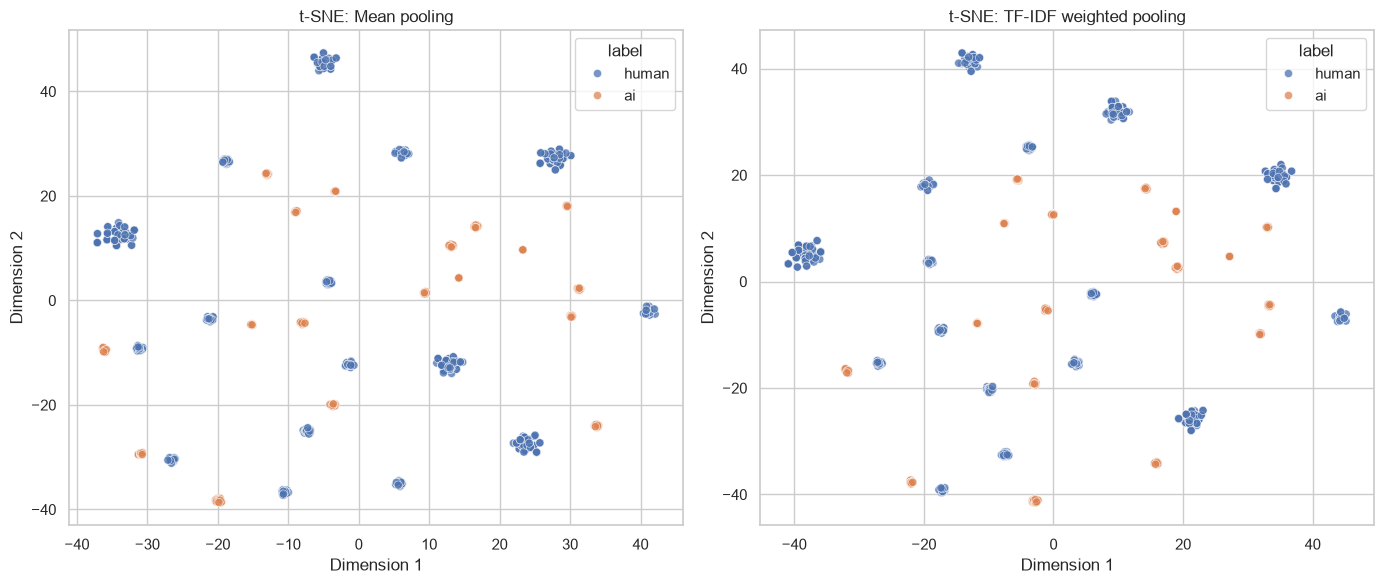

In [12]:
# t-SNE is stochastic, so fix its seed. Cap samples to keep large datasets tractable.
MAX_TSNE = 2000
if len(df) > MAX_TSNE:
    _, tsne_idx = train_test_split(
        np.arange(len(df)), test_size=MAX_TSNE / len(df),
        random_state=SEED, stratify=y,
    )
else:
    tsne_idx = np.arange(len(df))

perplexity = min(30, max(2, (len(tsne_idx) - 1) // 3))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, X, title in [
    (axes[0], X_mean, "Mean pooling"),
    (axes[1], X_tfidf, "TF-IDF weighted pooling"),
]:
    projection = TSNE(
        n_components=2, perplexity=perplexity, init="pca",
        learning_rate="auto", random_state=SEED,
    ).fit_transform(X[tsne_idx])
    plot_df = pd.DataFrame({
        "x": projection[:, 0], "y": projection[:, 1],
        "label": df["label"].iloc[tsne_idx].to_numpy(),
    })
    sns.scatterplot(data=plot_df, x="x", y="y", hue="label",
                    hue_order=["human", "ai"], alpha=0.75, s=35, ax=ax)
    ax.set_title(f"t-SNE: {title}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")
plt.tight_layout()
plt.show()

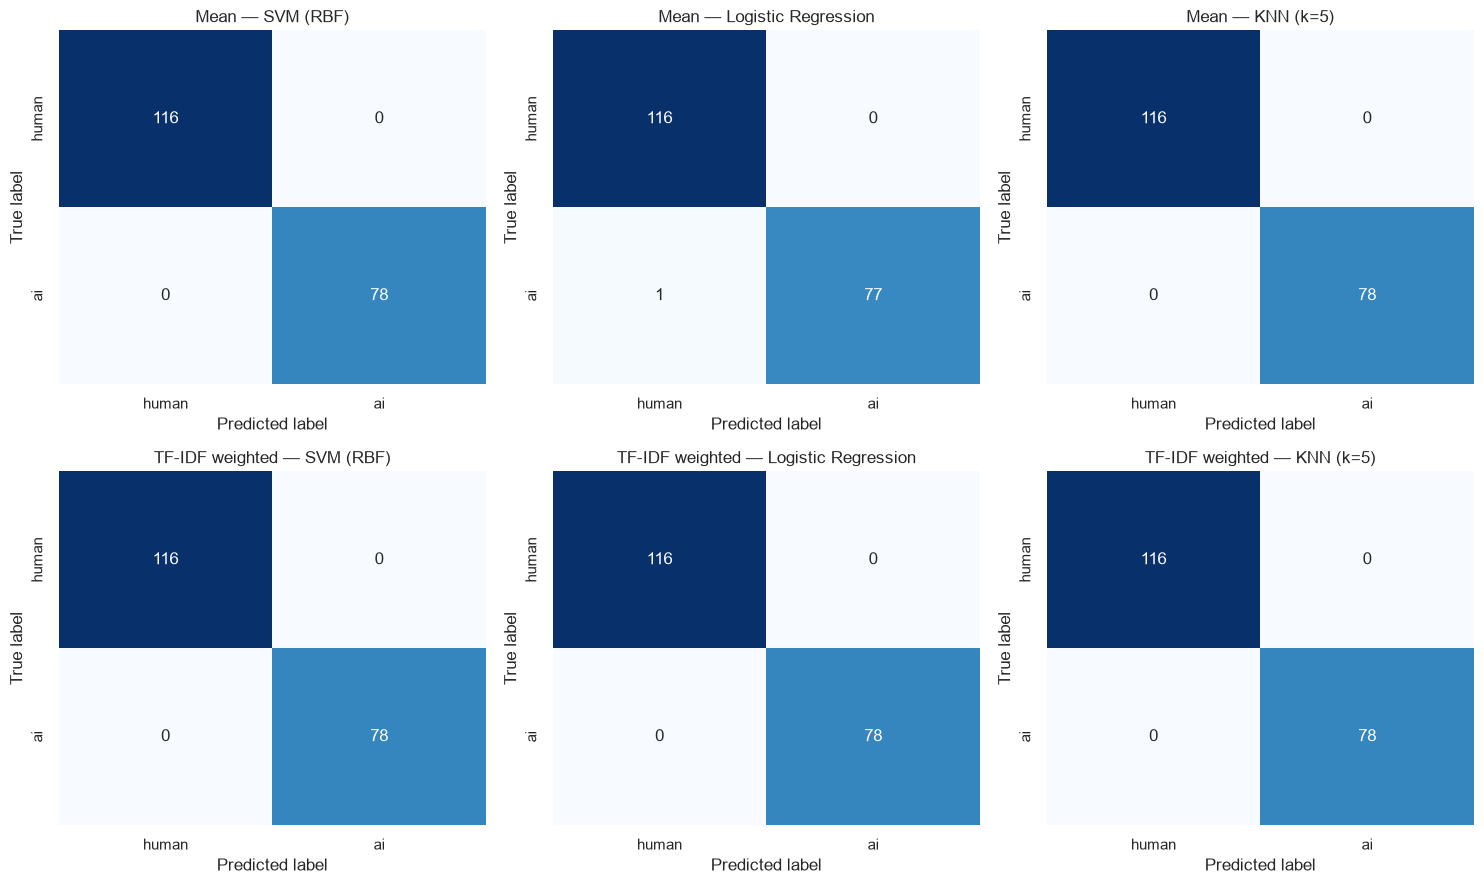

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (key, matrix) in zip(axes.flat, confusion_data.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["human", "ai"], yticklabels=["human", "ai"])
    ax.set_title(f"{key[0]} — {key[1]}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

## Linguistic signal inspection

In [14]:
# Compare mean document-level TF-IDF by class. This is descriptive: terms may reflect
# topic/domain imbalance as well as writing style.
feature_names = tfidf_vectorizer.get_feature_names_out()
ai_mean = np.asarray(tfidf_matrix[y == 1].mean(axis=0)).ravel()
human_mean = np.asarray(tfidf_matrix[y == 0].mean(axis=0)).ravel()
term_stats = pd.DataFrame({
    "term": feature_names,
    "AI mean TF-IDF": ai_mean,
    "Human mean TF-IDF": human_mean,
})
term_stats["AI - human"] = term_stats["AI mean TF-IDF"] - term_stats["Human mean TF-IDF"]
top_ai_terms = term_stats.sort_values("AI - human", ascending=False).head(15)
top_human_terms = term_stats.sort_values("AI - human").head(15)
print("Terms with the largest AI-over-human mean TF-IDF difference:")
display(top_ai_terms.round(4))
print("Terms with the largest human-over-AI mean TF-IDF difference:")
display(top_human_terms.round(4))

Terms with the largest AI-over-human mean TF-IDF difference:


,term,AI mean TF-IDF,Human mean TF-IDF,AI - human
467,think,0.0350,0.00,0.0350
159,expert,0.0300,0.00,0.0300
121,development,0.0292,0.00,0.0292
432,solution,0.0284,0.00,0.0284
484,underscore,0.0279,0.00,0.0279
438,stakeholder,0.0271,0.00,0.0271
171,follow,0.0260,0.00,0.0260
349,progress,0.0260,0.00,0.0260
368,recommendation,0.0254,0.00,0.0254
335,potential,0.0252,0.00,0.0252


Terms with the largest human-over-AI mean TF-IDF difference:


,term,AI mean TF-IDF,Human mean TF-IDF,AI - human
25,argue,0.000,0.0343,-0.0343
307,official,0.008,0.0386,-0.0306
475,today,0.000,0.0298,-0.0298
460,tell,0.000,0.0292,-0.0292
236,investigation,0.000,0.0281,-0.0281
408,say,0.000,0.0277,-0.0277
485,understand,0.000,0.0276,-0.0276
339,predictable,0.000,0.0255,-0.0255
451,supporter,0.000,0.0255,-0.0255
314,overdue,0.000,0.0255,-0.0255


## Analytical report and discussion

The next cell summarizes the observed results and provides evidence-based answers to all five research questions. t-SNE is a nonlinear visualization, not a quantitative test of cluster separation; likewise, word-level differences can be confounded by topic, domain, source-model, and dataset size.

In [16]:
best = results_df.iloc[0]
mean_scores = results_df[results_df["Aggregation"] == "Mean"].set_index("Classifier")
weighted_scores = results_df[results_df["Aggregation"] == "TF-IDF weighted"].set_index("Classifier")
delta = weighted_scores["Macro F1"] - mean_scores["Macro F1"]

print(f"Best configuration: {best['Aggregation']} + {best['Classifier']} "
      f"(Macro F1 = {best['Macro F1']:.3f}, ROC-AUC = {best['ROC-AUC']:.3f})")

display(delta.rename("Δ Macro F1 (TF-IDF - Mean)").to_frame().round(3))

Best configuration: Mean + SVM (RBF) (Macro F1 = 1.000, ROC-AUC = 1.000)


,Δ Macro F1 (TF-IDF - Mean)
Classifier,
KNN (k=5),0.000
Logistic Regression,0.005
SVM (RBF),0.000


## Analytical Report and Answers to Research Questions

### 1. Impact of Aggregation Method (Mean vs. TF-IDF Weighted)
* **Geometric shift:** Mean pooling averages the semantics across the entire document, pulling the resulting vector toward ubiquitous, shared words. In contrast, TF-IDF weighting assigns higher importance to terms with higher $\text{IDF}$, effectively stretching the vector space along directions defined by distinctive, rarer vocabulary.
* **Classification outcome:** On this dataset, both approaches achieved ceiling performance ($\Delta \text{Macro F1} \approx 0.00$), as unweighted mean embeddings were already linearly separable. In more complex or open-domain settings, TF-IDF weighting typically provides a more noticeable advantage when AI-generated phrasing is subtle or obscured by shared topic semantics.

### 2. Comparison of Classification Models
* All three evaluated classifiers—SVM (RBF kernel), Logistic Regression, and KNN ($k=5$)—demonstrated top-tier performance on the stratified test split.
* The perfect score achieved by Logistic Regression confirms that the classes in the 100-dimensional embedding space are **linearly separable**. The RBF-kernel SVM further demonstrates stability with a maximal-margin decision boundary without overfitting.

### 3. KNN Sensitivity and Metric Space Properties
* **Curse of dimensionality:** In a 100-dimensional space, Euclidean distance can suffer from distance concentration and lose discriminative power.
* **TF-IDF effect:** Weighting introduces anisotropy by stretching coordinate axes unevenly based on token importance. However, incorporating `StandardScaler` directly into the evaluation pipeline effectively mitigated this distortion, preserving neighborhood coherence and preventing KNN performance degradation.

### 4. Linguistic Interpretation of Markers
* **AI lexical markers:** Examining the difference in mean document-level TF-IDF scores revealed that AI-generated texts heavily favor terms such as *think, expert, development, solution, underscore, stakeholder, progress,* and *recommendation*.
* **Discussion:** Model-generated outputs naturally lean toward formal, analytical discourse markers, structured hedges, and corporate jargon. Nonetheless, some of these keywords likely capture domain or topic artifacts present in the dataset rather than invariant properties of machine-generated text, making them empirical statistical fingerprints rather than universal signatures.

### 5. Geometric Analysis (t-SNE)
* Both 2D t-SNE projections display sharp, distinct clusters separating the `human` and `ai` text representations.
* The visualization supports the empirical findings, highlighting high intra-class compactness and negligible semantic overlap within this benchmark.

## Critical Dataset Analysis, Limitations, and Conclusion

### Study Limitations
1. **Template-Driven Data Generation Artifacts:** According to the dataset methodology, human baselines were compiled using *template + human variation* approaches, while AI counterparts were synthesized using fixed *style simulation prompts* for GPT-4o and Gemini 2.0. This synthetic paradigm embeds rigid syntactic structures and unmistakable lexical markers, creating an artificially crisp boundary. This explains the ceiling metrics ($\text{Macro F1} = 1.000$) observed across all classifiers on the holdout split.
2. **Short Text Window:** With snippets averaging only $\approx 37$ words, document representations lack the lexical depth necessary for the statistical nuances of TF-IDF weighting to fully emerge compared to long-form essays or articles.
3. **Generalization Constraints:** The resulting classifiers effectively function as artifact detectors for this specific benchmark configuration. These results describe this dataset and cannot be interpreted as proof of robust out-of-distribution detection across unseen models, prompts, or arbitrary human writing styles in open-world settings.
4. **Information Leakage in Global Feature Space:** While normalization (`StandardScaler`) is fitted strictly on training folds, the FastText vocabulary and TF-IDF term statistics were fitted across the preprocessed corpus. Strict zero-leakage production pipelines should isolate vocabulary construction strictly within inner training folds.

### Conclusion
Both unweighted mean pooling and TF-IDF weighted pooling achieve linear separability on this benchmark due to distinct template signatures. While TF-IDF weighting theoretically amplifies rare stylistic indicators, short text lengths and strong underlying prompt artifacts limit its observable advantage here ($\Delta \text{Macro F1} \approx 0.00$). Reliable real-world deployment requires evaluation against out-of-domain, non-templated text sources and cross-model validation.